## Scatter Matrix

In [61]:
import pandas as pd
import sqlite3
from pandas.plotting import scatter_matrix

In [62]:
conn=sqlite3.connect('../data/checking-logs.sqlite')

query="""
SELECT uid, COUNT(*) AS view_count
FROM pageviews
WHERE uid LIKE 'user%'
GROUP BY uid;
"""

views=pd.read_sql_query(query, conn)
views

,uid,view_count
0,user_1,28
1,user_10,89
2,user_14,143
3,user_17,47
4,user_18,3
5,user_19,16
6,user_21,10
7,user_25,179
8,user_28,149
9,user_3,317


In [63]:
query="""
SELECT uid, COUNT(*) AS commit_count
FROM checker
WHERE labname != 'project1'
  AND uid LIKE 'user%'
GROUP BY uid;
"""

commits=pd.read_sql_query(query, conn)
commits

,uid,commit_count
0,user_0,3
1,user_1,62
2,user_10,20
3,user_11,7
4,user_12,86
5,user_13,52
6,user_14,61
7,user_15,23
8,user_16,41
9,user_17,51


In [64]:

avg_diff = pd.read_csv('../data/ab-test.csv')
avg_diff

,uid,diff,time,group
0,user_1,-103.333333,after,test
1,user_1,-6.000000,before,test
2,user_18,-10.000000,after,test
3,user_18,-3.500000,before,test
4,user_19,-82.333333,after,test
5,user_19,-148.000000,before,test
6,user_21,-78.500000,after,test
7,user_21,-112.500000,before,test
8,user_25,-127.500000,after,test
9,user_25,-69.333333,before,test


In [65]:
avg_diff=avg_diff.loc[avg_diff['group']=='test'].groupby(['uid'])['diff'].mean()
avg_diff=pd.DataFrame(avg_diff)
avg_diff

,diff
uid,
user_1,-54.666667
user_18,-6.750000
user_19,-115.166667
user_21,-95.500000
user_25,-98.416667
user_28,-94.750000
user_3,-114.250000


In [66]:
merged=avg_diff.merge(views, on='uid', how='left').merge(commits, on='uid', how='left')
merged

,uid,diff,view_count,commit_count
0,user_1,-54.666667,28,62
1,user_18,-6.750000,3,5
2,user_19,-115.166667,16,118
3,user_21,-95.500000,10,65
4,user_25,-98.416667,179,79
5,user_28,-94.750000,149,60
6,user_3,-114.250000,317,18


array([[<Axes: xlabel='diff', ylabel='diff'>,
        <Axes: xlabel='view_count', ylabel='diff'>,
        <Axes: xlabel='commit_count', ylabel='diff'>],
       [<Axes: xlabel='diff', ylabel='view_count'>,
        <Axes: xlabel='view_count', ylabel='view_count'>,
        <Axes: xlabel='commit_count', ylabel='view_count'>],
       [<Axes: xlabel='diff', ylabel='commit_count'>,
        <Axes: xlabel='view_count', ylabel='commit_count'>,
        <Axes: xlabel='commit_count', ylabel='commit_count'>]],
      dtype=object)

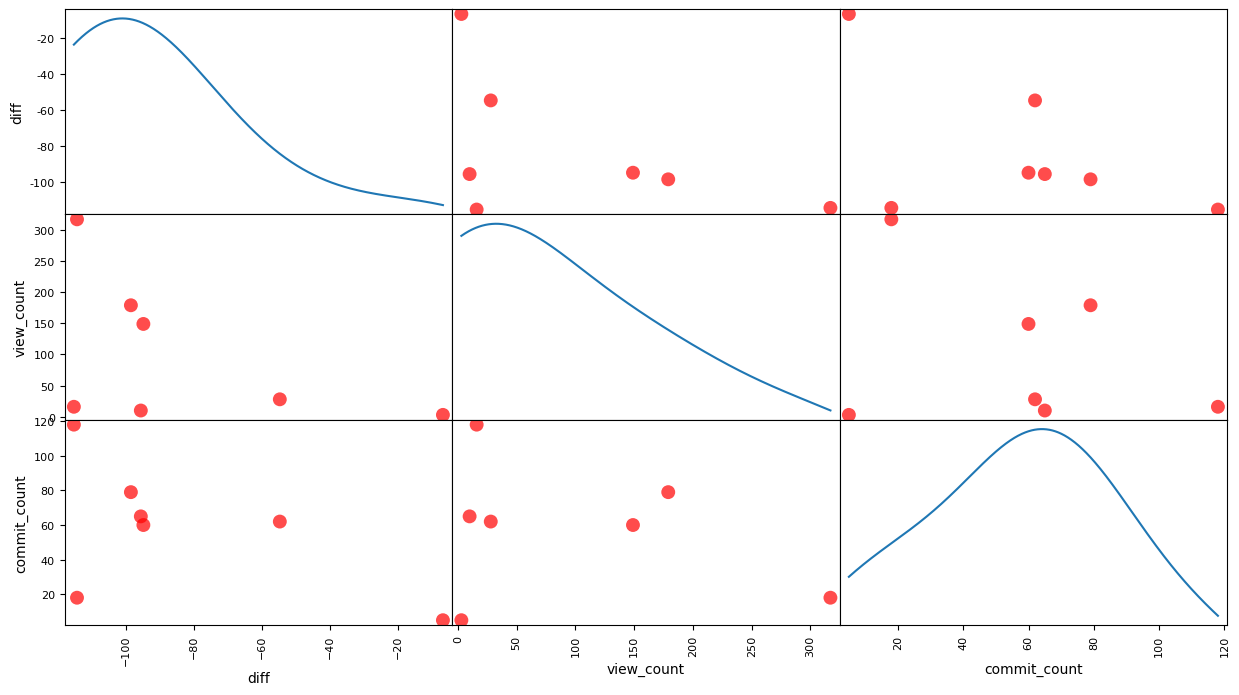

In [67]:

scatter_matrix(
    merged,
    diagonal='kde',
    figsize=(15, 8),
    c='red',
    s=100,
    marker='o',
    alpha=0.7
)

### "Can we say that if a user has a low number of pageviews, then they likely have a low number of commits?"
```The answer is NO```

### "Can we say that if a user has a low number of pageviews, then they likely have a small average difference between the first commit and the lab deadline?"
```The answer is NO```

### "Can we say that there are many users with a low number of commits and a few with a high number of commits?"
```The answer is YES```

### "Can we say that there are many users with a small average difference and a few with a large average difference?"
```The answer is YES```

In [68]:
conn.close()